In [58]:
!pip install -q keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 1.7 MB/s eta 0:00:00


In [59]:
# Standard libs
import os
import random
import warnings

# Data science
import numpy as np
import pandas as pd
from sklearn.utils import shuffle

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility + warnings
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
warnings.filterwarnings("ignore")

# sklearn utilities
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_auc_score,
    roc_curve,
)

# from sklearn.tree import DecisionTreeClassifier
# from sklearn.utils.class_weight import compute_class_weight
# from sklearn import tree



# TensorFlow / Keras (use tensorflow.keras to avoid mixing backends)
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, BatchNormalization
from keras.callbacks import EarlyStopping
from keras.optimizers import Adam, RMSprop
import keras.layers as layers


# Hyperparameter tuning (Keras Tuner)
import keras_tuner as kt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/ML/ModelHub/Churn/Telco-Customer-Churn.csv')

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
df.shape


(7043, 21)

In [9]:
df.isna().sum().sum()

np.int64(0)

In [11]:
df.duplicated().sum()

np.int64(0)

In [13]:
numerical = ['tenure','MonthlyCharges','SeniorCitizen']

for col in numerical:
  print(f"\n{col}")
  print(f"  Range      : {df[col].min():.2f} to {df[col].max():.2f}")
  print(f"  Mean       : {df[col].mean():.2f}")
  print(f"  Median     : {df[col].median():.2f}")
  print(f"  Std Dev    : {df[col].std():.2f}")


tenure
  Range      : 0.00 to 72.00
  Mean       : 32.37
  Median     : 29.00
  Std Dev    : 24.56

MonthlyCharges
  Range      : 18.25 to 118.75
  Mean       : 64.76
  Median     : 70.35
  Std Dev    : 30.09

SeniorCitizen
  Range      : 0.00 to 1.00
  Mean       : 0.16
  Median     : 0.00
  Std Dev    : 0.37


In [14]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print("Churn Counts:")
print(churn_counts)
print("\nChurn Percentages:")
print(churn_pct.map('{:.2f}%'.format))

print(f"\nClass Imbalance Ratio (No:Yes): {churn_counts['No']/churn_counts['Yes']:.2f}:1")

Churn Counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Percentages:
Churn
No     73.46%
Yes    26.54%
Name: proportion, dtype: object

Class Imbalance Ratio (No:Yes): 2.77:1


In [15]:
senior_counts = df['SeniorCitizen'].value_counts().sort_index()
senior_pct = df['SeniorCitizen'].value_counts(normalize=True).sort_index() * 100

print("SeniorCitizen (0=No, 1=Yes):")
print(senior_counts)
print("\nPercentages:")
print(senior_pct.map('{:.2f}%'.format))
print(f"Percentage of seniors: {(df['SeniorCitizen'] == 1).mean()*100:.2f}%")

SeniorCitizen (0=No, 1=Yes):
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

Percentages:
SeniorCitizen
0    83.79%
1    16.21%
Name: proportion, dtype: object
Percentage of seniors: 16.21%


# Exploatory Data Analsis

In this section we can observe how the features are align with the Predictor variable

This graph represent a significant Class imbalance
where it could affect the prediction of Churn in the model

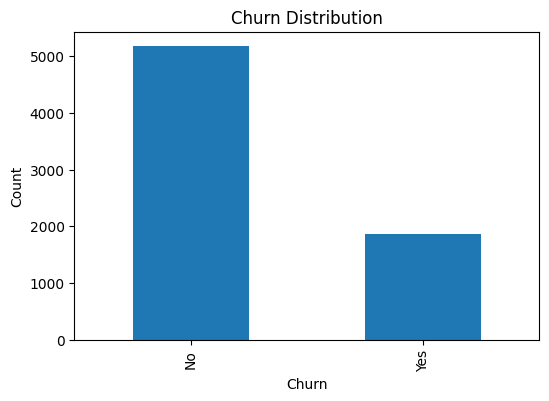

In [16]:
plt.figure(figsize=(6,4))
df['Churn'].value_counts().plot(kind='bar')
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

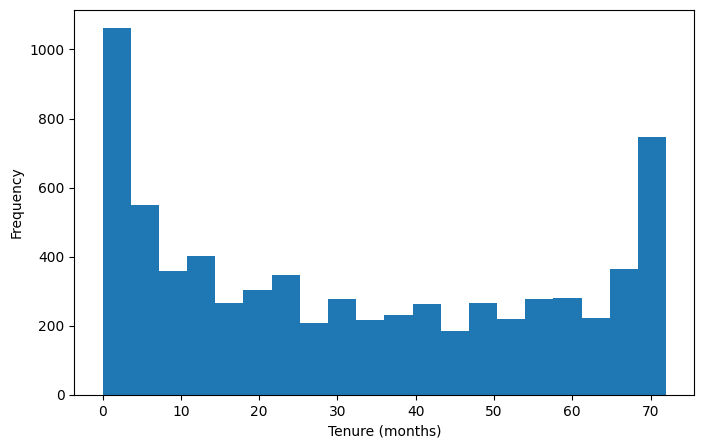

In [17]:
plt.figure(figsize=(8,5))
plt.hist(df['tenure'], bins=20)
plt.title("")
plt.xlabel("Tenure (months)")
plt.ylabel("Frequency")
plt.show()

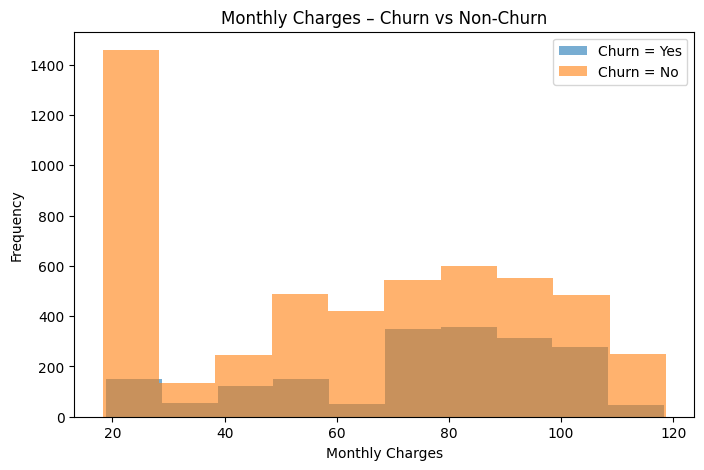

In [18]:
plt.figure(figsize=(8,5))
df[df['Churn']=="Yes"]['MonthlyCharges'].plot(kind='hist', alpha=0.6, label="Churn = Yes")
df[df['Churn']=="No"]['MonthlyCharges'].plot(kind='hist', alpha=0.6, label="Churn = No")
plt.legend()
plt.title("Monthly Charges – Churn vs Non-Churn")
plt.xlabel("Monthly Charges")
plt.show()

<Figure size 700x400 with 0 Axes>

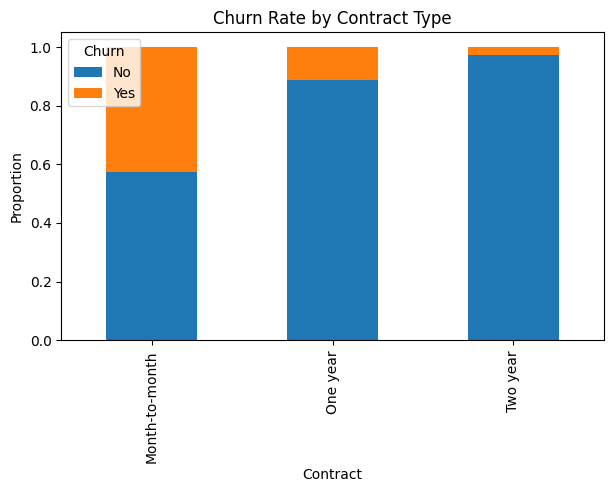

In [19]:
plt.figure(figsize=(7,4))
(df.groupby("Contract")['Churn']
   .value_counts(normalize=True)
   .unstack()
   .plot(kind='bar', stacked=True, figsize=(7,4)))
plt.title("Churn Rate by Contract Type")
plt.ylabel("Proportion")
plt.show()

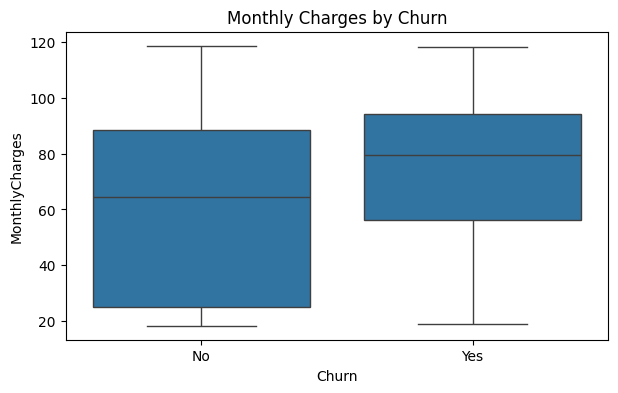

In [20]:
import seaborn as sns

plt.figure(figsize=(7,4))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges by Churn")
plt.show()

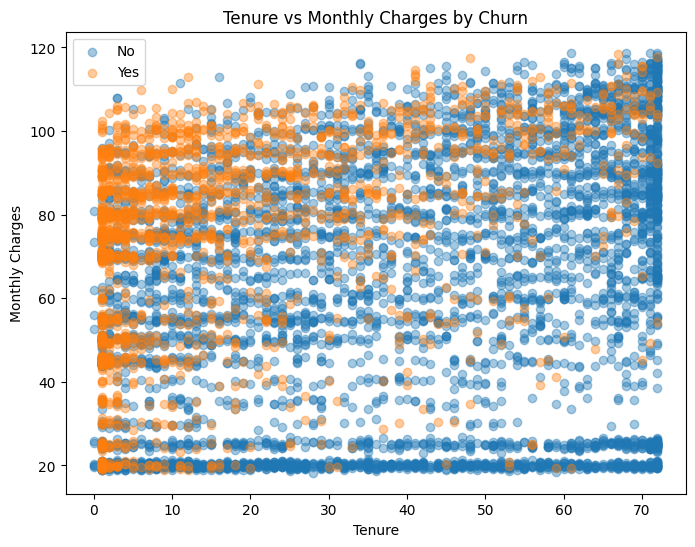

In [21]:
plt.figure(figsize=(8,6))
for label, group in df.groupby('Churn'):
    plt.scatter(group['tenure'], group['MonthlyCharges'], label=label, alpha=0.4)

plt.legend()
plt.title("Tenure vs Monthly Charges by Churn")
plt.xlabel("Tenure")
plt.ylabel("Monthly Charges")
plt.show()

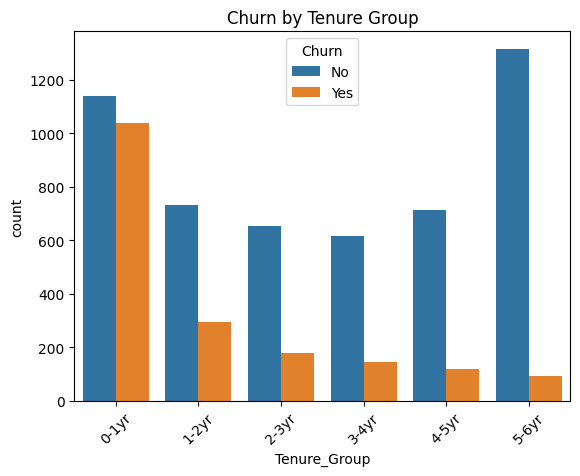

In [22]:
df['Tenure_Group'] = pd.cut(df['tenure'], bins=[0,12,24,36,48,60,72], labels=['0-1yr','1-2yr','2-3yr','3-4yr','4-5yr','5-6yr'])
sns.countplot(x='Tenure_Group', hue='Churn', data=df)
plt.title('Churn by Tenure Group')
plt.xticks(rotation=45)
plt.show()

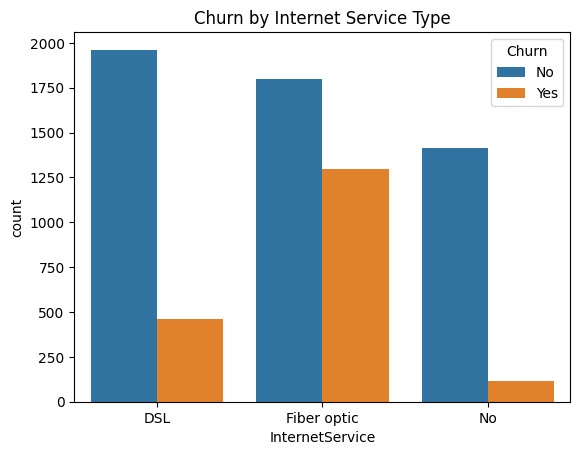

In [25]:
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.title('Churn by Internet Service Type')
plt.show()

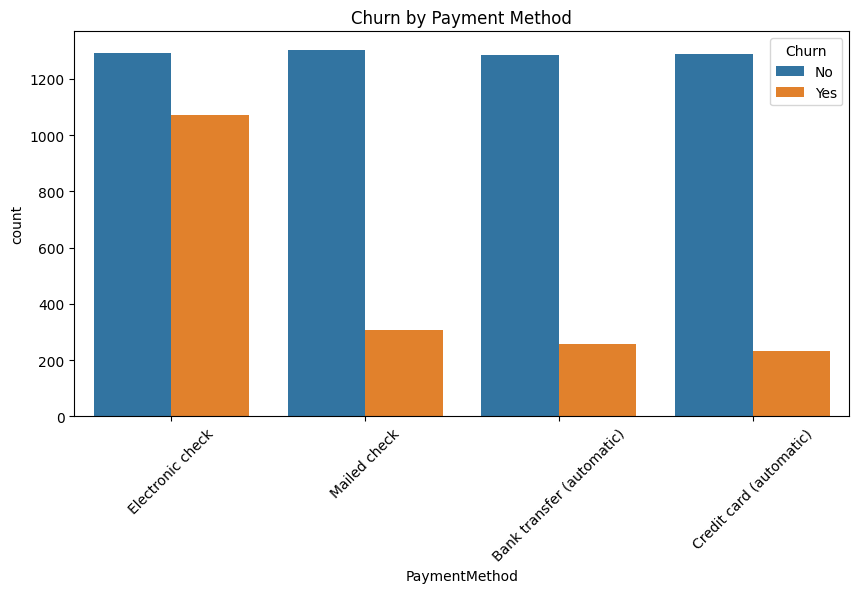

In [24]:
plt.figure(figsize=(10,5))
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.xticks(rotation=45)
plt.title('Churn by Payment Method')
plt.show()

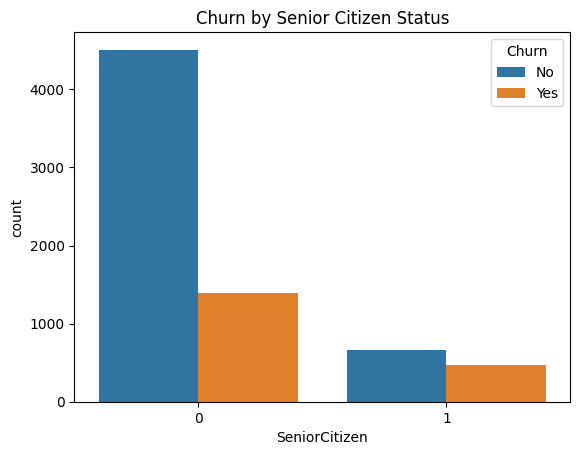

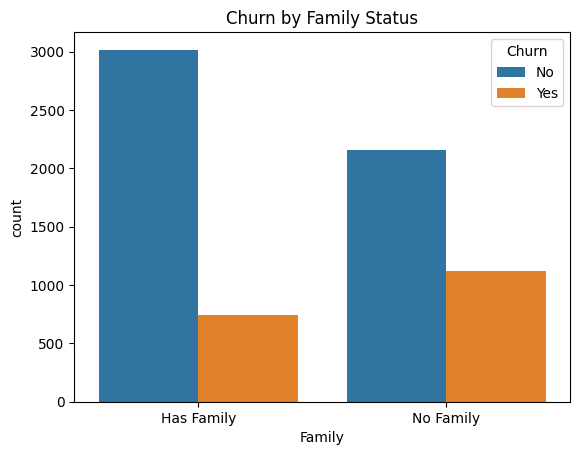

In [23]:
# Combine Partner and Dependents
df['Family'] = ((df['Partner']=='Yes') | (df['Dependents']=='Yes')).map({True:'Has Family', False:'No Family'})
sns.countplot(x='SeniorCitizen', hue='Churn', data=df)
plt.title('Churn by Senior Citizen Status')
plt.show()

sns.countplot(x='Family', hue='Churn', data=df)
plt.title('Churn by Family Status')
plt.show()

# Data Preprocessing
clean, modular, production-ready Python preprocessing chunks for a Customer Churn Prediction System.

In [26]:
df = shuffle(df, random_state=42)

In [27]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [28]:
df.drop('customerID' , axis = 1 , inplace = True)


In [36]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')  # or 'mean'
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

In [37]:
print(X.isnull().sum()[X.isnull().sum() > 0])
print(f"Total NaN cells: {X.isnull().sum().sum()}")

Series([], dtype: int64)
Total NaN cells: 0


In [38]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [39]:
y = y.map({'Yes':1, 'No':0})

In [40]:
X = pd.get_dummies(X , drop_first=True)


In [41]:
X.shape

(7043, 36)

In [42]:
y.shape

(7043,)

Applying SMOTE for the Data set to treat the class imbalance

<Axes: xlabel='Churn'>

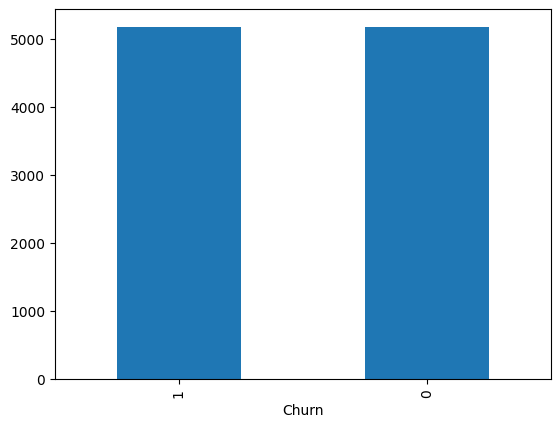

In [47]:
from sklearn.impute import SimpleImputer
from imblearn.pipeline import Pipeline

pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('smote', smote)
])
X_smote, y_smote = pipeline.fit_resample(X, y)

y_smote_value = y_smote.value_counts()
y_smote_value.plot(kind="bar")

In [50]:
X_train, X_test, y_train, y_test = train_test_split(X_smote, y_smote, test_size=0.2, random_state=42)


In [51]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [52]:
X_train.shape

(8278, 36)

In [53]:
X_test.shape

(2070, 36)

In [54]:
y_train.shape

(8278,)

In [55]:
y_test.shape

(2070,)

In [56]:
input_dim = X_train.shape[1]

# This ANN will give you
* Fully functional ANN for churn classification
* Dropout to prevent overfitting
* Early stopping to avoid unnecessary training
* Accuracy, classification report, and confusion matrix
* Clean output ready for a report or notebook

In [60]:
model = Sequential([
    Dense(32 , activation='relu', input_shape=(X_train.shape[1],)),
    Dense(16 , activation='relu'),
    Dense(1 , activation='sigmoid')
])

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [61]:
model.add(Dense(32, activation='relu', input_dim=input_dim))
model.add(Dropout(0.2))

model.add(Dense(16, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(1, activation='sigmoid'))

In [64]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True)

history = model.fit(
    X_train,y_train,
    validation_split = 0.2,
    batch_size = 32,
    epochs = 100,
    callbacks = [early_stopping],
    verbose = 1)


Epoch 1/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6134 - loss: 0.6612 - val_accuracy: 0.7778 - val_loss: 0.5453
Epoch 2/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7793 - loss: 0.5373 - val_accuracy: 0.7880 - val_loss: 0.4902
Epoch 3/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7921 - loss: 0.4899 - val_accuracy: 0.7868 - val_loss: 0.4723
Epoch 4/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7898 - loss: 0.4794 - val_accuracy: 0.7953 - val_loss: 0.4583
Epoch 5/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7863 - loss: 0.4789 - val_accuracy: 0.8056 - val_loss: 0.4456
Epoch 6/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7955 - loss: 0.4594 - val_accuracy: 0.8086 - val_loss: 0.4347
Epoch 7/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8100 - loss: 0.4319 - val_accuracy: 0.8013 - val_loss: 0.4347
Epoch 8/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8095 - loss: 0.4300 - val_accu

In [65]:
y_pred = (model.predict(X_test) > 0.5).astype("int32")

accuracy_score(y_test, y_pred)
classification_report(y_test, y_pred)

# Confusion matrix
confusion_matrix(y_test, y_pred)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Accuracy: 0.8188 (81.88%)
Precision: 0.7868284228769498
Recall: 0.875602700096432
F1: 0.8288452761296212
ROC AUC: 0.8187306820908105
Confusion Matrix:
 [[787 246]
 [129 908]]


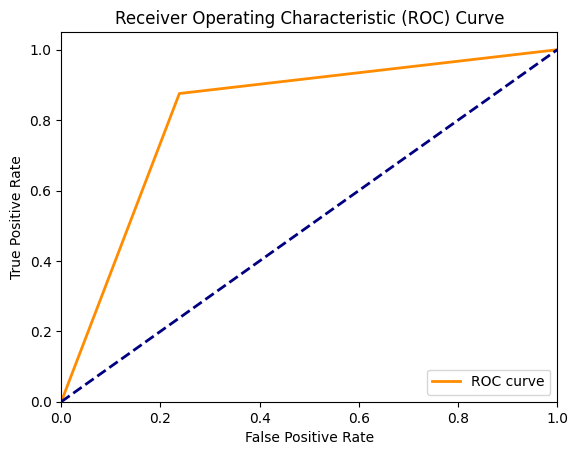

np.float64(0.8187306820908105)

In [66]:
#ROC curve for the ANN
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

#ROC accuracy
roc_auc_score(y_test, y_pred)

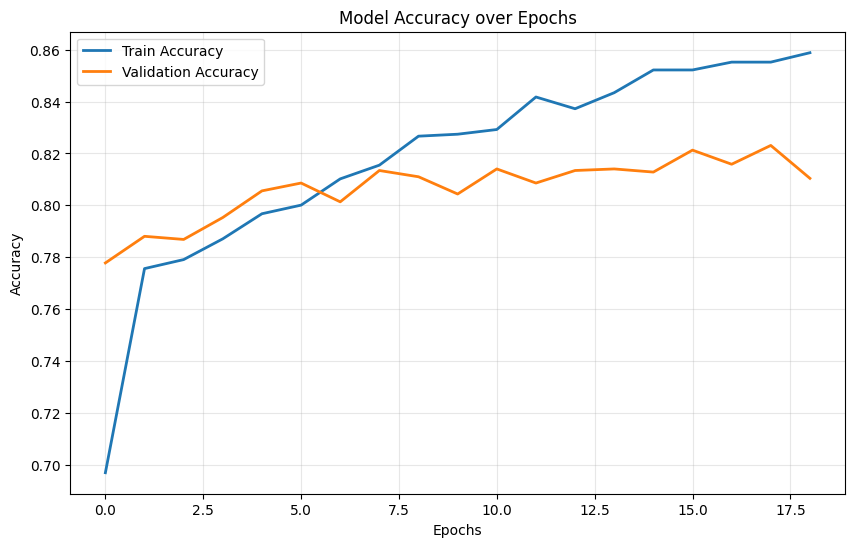

In [67]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
plt.title('Model Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

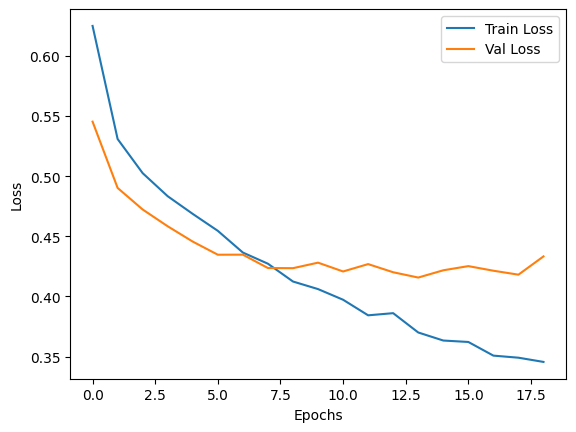

In [68]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

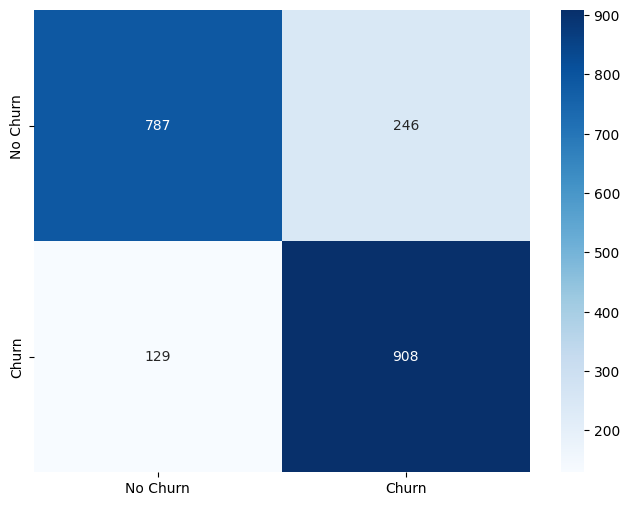

In [69]:
#Confusion metrix for the ANN
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt

* **Steady Decreasein Both Losses**: The training loss (blue) drops sharply at first and continues decreasing smoothly, while validation loss (orange) follows a similar downward trend. This shows your ANN is effectively learning patterns from the data without getting stuck.

* **Low Overfitting Evidence**: There's a small, consistent gap between train and validation loss, but it doesn't widen over epochs. This means your model generalizes well to unseen data and isn't memorizing the training set.

* **Stable Validation Performance**: After around epoch 10, validation loss flattens out without rising — a clear sign of convergence. No upward trend indicates no overfitting, even as training continues.

* **Healthy Convergence**: The model reaches a low loss (~0.40–0.45) by epoch 15–18, with both curves stabilizing. This is ideal for a small tabular dataset like Telco Churn, showing you've captured most learnable patterns.

* **No Red Flags Overall**: The curve is smooth, balanced, and plateaus naturally — classic signs of a well-trained, well-behaved ANN.